# Movie Recommendation System — Machine Learning Project

| Field | Details |
|-------|---------|
| **Name** | Rakshit Thakur |
| **Roll No.** | 2023BTCSE013 |
| **JLU ID** | JLU07720 |
| **Course** | Machine Learning |
| **Dataset** | MovieLens 100K (ml-100k) |

---

## Project Overview

This notebook implements a complete ML-based **Movie Recommendation System** using the MovieLens 100K dataset.  
It covers all four modules of the ML course:

| Module | Coverage |
|--------|----------|
| **Module 1** | Problem definition, data loading, EDA, cleaning, visualizations |
| **Module 2** | Supervised baseline — predicting user ratings (regression) |
| **Module 3** | Feature scaling, regularization, K-Means clustering, PCA |
| **Module 4** | Decision Tree, Random Forest, hyperparameter tuning, final model selection |

---

## Problem Statement

**Goal:** Predict the rating (1–5) a user will give to a movie they haven't seen yet.  
This is framed as a **supervised regression / classification problem**.  
We also apply **unsupervised learning** (K-Means, PCA) to discover user and movie clusters.


---
#  Module 1 — Data Understanding & Preprocessing

## 1.1 Import Libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings, os, zipfile, urllib.request

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully.")


All libraries imported successfully.


## 1.2 Download & Load the MovieLens 100K Dataset

In [37]:
# Download MovieLens 100K dataset
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
DATA_DIR = "ml-100k"

if not os.path.exists(DATA_DIR):
    print(" Downloading MovieLens 100K...")
    urllib.request.urlretrieve(DATA_URL, "ml-100k.zip")
    with zipfile.ZipFile("ml-100k.zip", 'r') as z:
        z.extractall(".")
    print(" Downloaded and extracted.")
else:
    print(" Dataset already present.")

# Load ratings
ratings = pd.read_csv(f"{DATA_DIR}/u.data", sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])

# Load movies
movies = pd.read_csv(f"{DATA_DIR}/u.item", sep='|', encoding='latin-1',
                     names=['movie_id','title','release_date','video_date','imdb_url',
                            'unknown','Action','Adventure','Animation','Children',
                            'Comedy','Crime','Documentary','Drama','Fantasy',
                            'Film-Noir','Horror','Musical','Mystery','Romance',
                            'Sci-Fi','Thriller','War','Western'])

# Load users
users = pd.read_csv(f"{DATA_DIR}/u.user", sep='|',
                    names=['user_id','age','gender','occupation','zip_code'])

print(f"Ratings shape : {ratings.shape}")
print(f"Movies shape  : {movies.shape}")
print(f"Users shape   : {users.shape}")


 Dataset already present.
Ratings shape : (100000, 4)
Movies shape  : (1682, 24)
Users shape   : (943, 5)


## 1.3 Exploratory Data Analysis (EDA)

In [38]:
# ── Basic info
print("=== RATINGS DATASET ===")
print(ratings.head())
print("\nData types:\n", ratings.dtypes)
print("\nMissing values:\n", ratings.isnull().sum())


=== RATINGS DATASET ===
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Data types:
 user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object

Missing values:
 user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


In [39]:
# ── Statistical summary
print("=== STATISTICAL SUMMARY ===")
print(ratings.describe())


=== STATISTICAL SUMMARY ===
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08


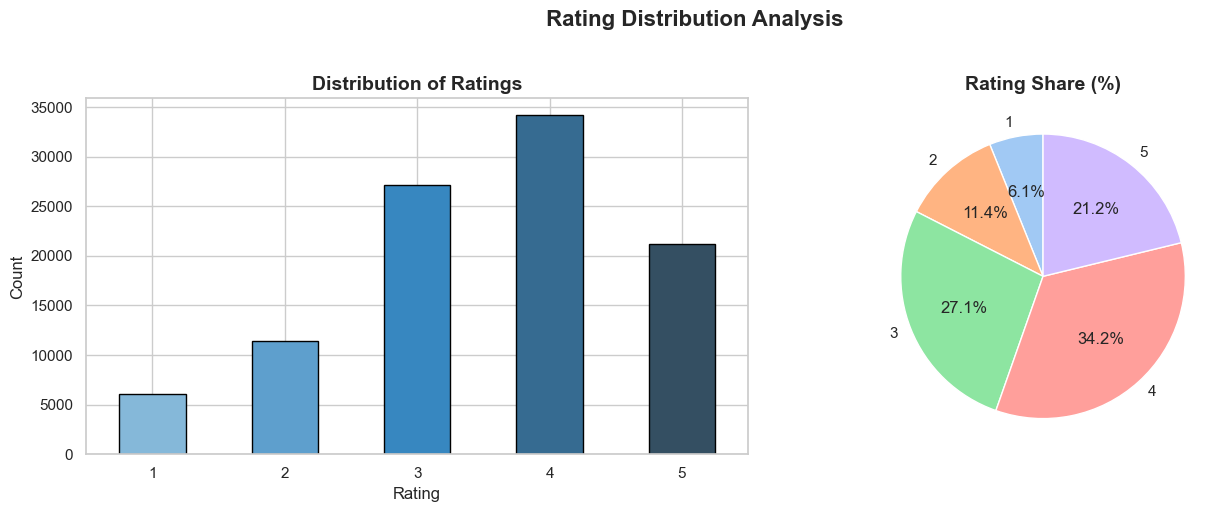

Observation: Ratings 3 and 4 dominate (~50%). Very few 1-star ratings.


In [40]:
# ── Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('Blues_d', 5), edgecolor='black')
axes[0].set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
ratings['rating'].value_counts().sort_index().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=sns.color_palette('pastel', 5), startangle=90)
axes[1].set_title('Rating Share (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle(' Rating Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_rating_distribution.png', bbox_inches='tight')
plt.show()
print("Observation: Ratings 3 and 4 dominate (~50%). Very few 1-star ratings.")


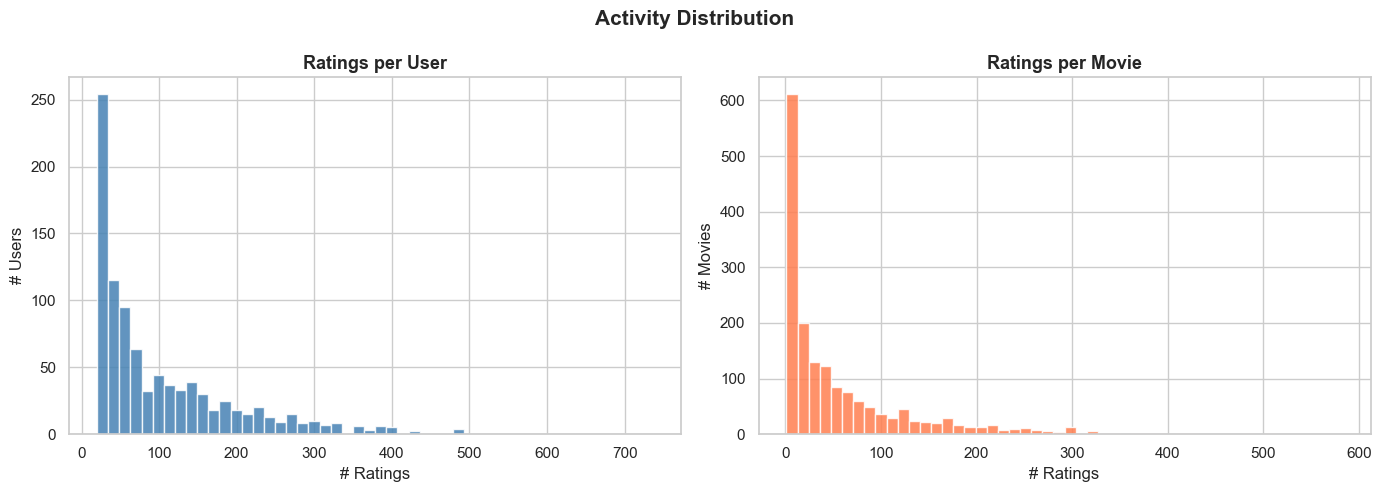

Avg ratings per user : 106.0
Avg ratings per movie: 59.5
Observation: Heavy-tailed distribution — a few users/movies dominate activity.


In [41]:
# ── Ratings per user & per movie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings_per_user = ratings.groupby('user_id')['rating'].count()
ratings_per_movie = ratings.groupby('movie_id')['rating'].count()

axes[0].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Ratings per User', fontsize=13, fontweight='bold')
axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Users')

axes[1].hist(ratings_per_movie, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Ratings per Movie', fontsize=13, fontweight='bold')
axes[1].set_xlabel('# Ratings'); axes[1].set_ylabel('# Movies')

plt.suptitle(' Activity Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_activity_distribution.png', bbox_inches='tight')
plt.show()

print(f"Avg ratings per user : {ratings_per_user.mean():.1f}")
print(f"Avg ratings per movie: {ratings_per_movie.mean():.1f}")
print("Observation: Heavy-tailed distribution — a few users/movies dominate activity.")


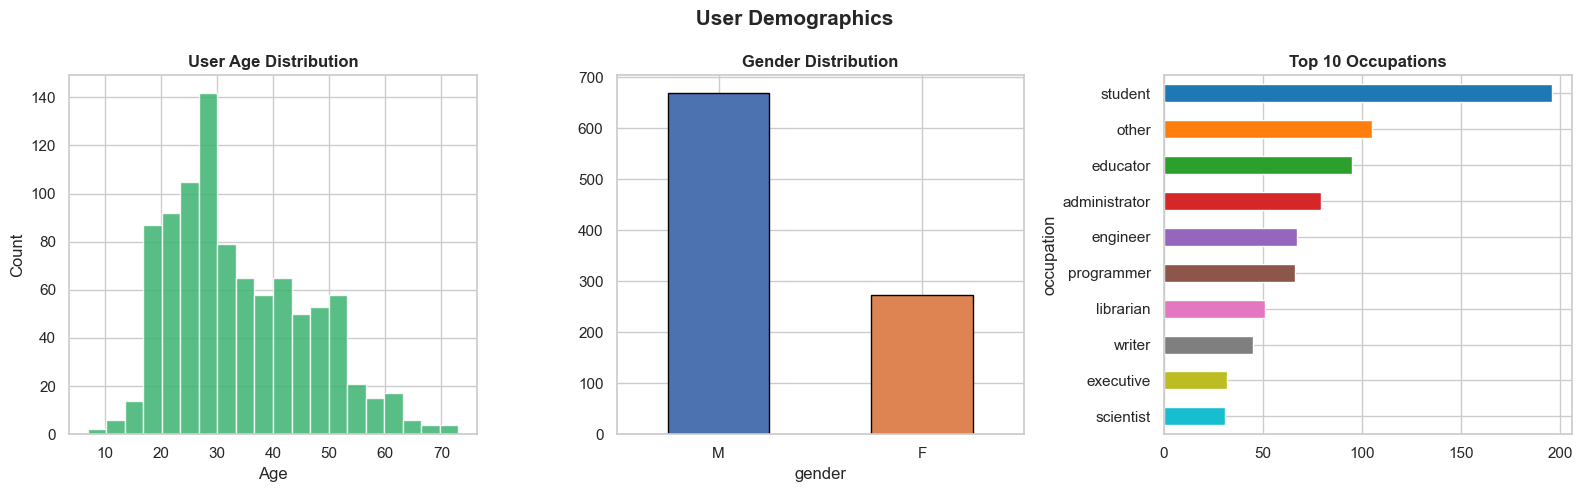

In [42]:
# ── User demographics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
axes[0].hist(users['age'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].set_title('User Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

# Gender distribution
users['gender'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#4C72B0','#DD8452'], edgecolor='black')
axes[1].set_title('Gender Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# Top occupations
users['occupation'].value_counts().head(10).plot(kind='barh', ax=axes[2],
    color=sns.color_palette('tab10', 10))
axes[2].set_title('Top 10 Occupations', fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle(' User Demographics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_demographics.png', bbox_inches='tight')
plt.show()


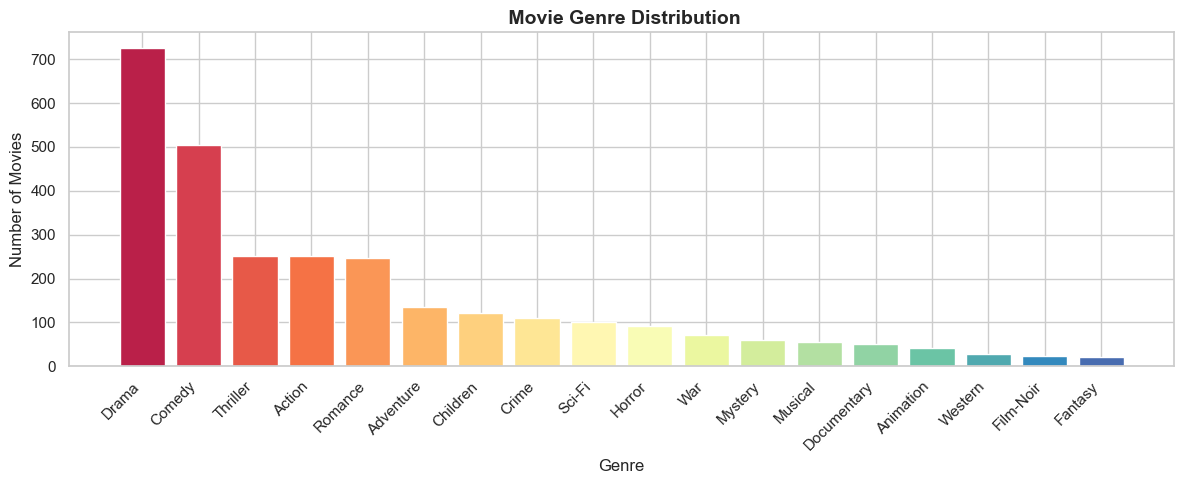

Observation: Drama and Comedy are the most common genres.


In [43]:
# ── Genre popularity
genre_cols = ['Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
              'Mystery','Romance','Sci-Fi','Thriller','War','Western']

genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(genre_counts.index, genre_counts.values,
               color=sns.color_palette('Spectral', len(genre_counts)))
plt.title(' Movie Genre Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Genre'); plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_genre_distribution.png', bbox_inches='tight')
plt.show()
print("Observation: Drama and Comedy are the most common genres.")


## 1.4 Data Merging & Feature Engineering

In [44]:
# Merge all three datasets
df = ratings.merge(users, on='user_id').merge(
         movies[['movie_id','title'] + genre_cols], on='movie_id')

# Drop timestamp (not useful for modeling)
df.drop('timestamp', axis=1, inplace=True)

# Encode gender
df['gender_encoded'] = (df['gender'] == 'M').astype(int)

# Encode occupation
le = LabelEncoder()
df['occupation_encoded'] = le.fit_transform(df['occupation'])

# User-level features
user_stats = df.groupby('user_id')['rating'].agg(['mean','count','std']).reset_index()
user_stats.columns = ['user_id','user_avg_rating','user_rating_count','user_rating_std']
user_stats['user_rating_std'].fillna(0, inplace=True)

# Movie-level features
movie_stats = df.groupby('movie_id')['rating'].agg(['mean','count','std']).reset_index()
movie_stats.columns = ['movie_id','movie_avg_rating','movie_rating_count','movie_rating_std']
movie_stats['movie_rating_std'].fillna(0, inplace=True)

# Merge back
df = df.merge(user_stats, on='user_id').merge(movie_stats, on='movie_id')

print(f"Final dataset shape: {df.shape}")
print("\nFeature columns:")
print(df.columns.tolist())
print("\nMissing values after merge:", df.isnull().sum().sum())


Final dataset shape: (100000, 34)

Feature columns:
['user_id', 'movie_id', 'rating', 'age', 'gender', 'occupation', 'zip_code', 'title', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'gender_encoded', 'occupation_encoded', 'user_avg_rating', 'user_rating_count', 'user_rating_std', 'movie_avg_rating', 'movie_rating_count', 'movie_rating_std']

Missing values after merge: 141


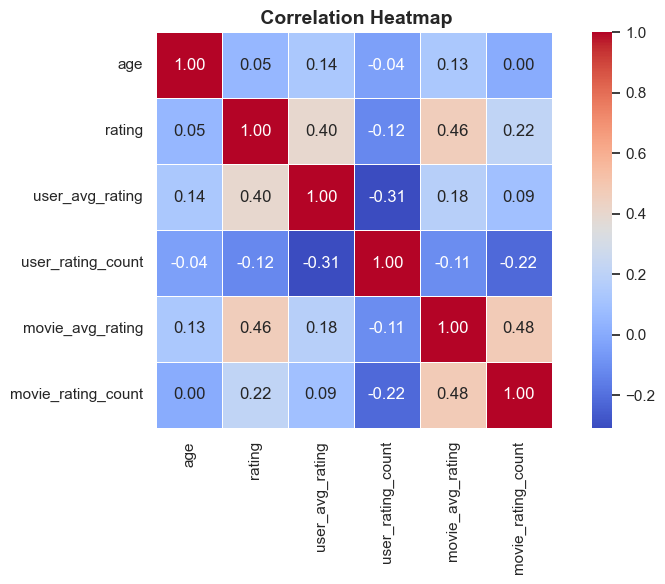

Observation: movie_avg_rating and user_avg_rating have the strongest correlation with rating.


In [45]:
# Correlation heatmap
num_cols = ['age','rating','user_avg_rating','user_rating_count',
            'movie_avg_rating','movie_rating_count']
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title(' Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Observation: movie_avg_rating and user_avg_rating have the strongest correlation with rating.")


---
#  Module 2 — Supervised Learning (Baseline Model)

## 2.1 Feature Selection & Train-Test Split

In [46]:
# Features for regression
feature_cols = ['age', 'gender_encoded', 'occupation_encoded',
                'user_avg_rating', 'user_rating_count', 'user_rating_std',
                'movie_avg_rating', 'movie_rating_count', 'movie_rating_std'] + genre_cols

X = df[feature_cols]
y = df['rating']

# Also prepare binary target for classification (like/dislike)
y_class = (y >= 4).astype(int)  # 1 = liked (4-5 stars), 0 = not liked

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"\nClass balance (classification):")
print(y_class.value_counts(normalize=True).rename({0:'Disliked', 1:'Liked'}))


Training set : (80000, 27)
Test set     : (20000, 27)

Class balance (classification):
rating
Liked       0.55375
Disliked    0.44625
Name: proportion, dtype: float64


## 2.2 Baseline Linear Regression

In [47]:
# ===== CLEAN TRAINING BLOCK =====

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Convert categorical → numeric
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

# Align train & test columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Handle missing values
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

# Fix target shape + missing values
if isinstance(y_train, pd.Series) or isinstance(y_train, pd.DataFrame):
    y_train = y_train.fillna(y_train.mean())
    y_train = y_train.values.ravel()

if isinstance(y_test, pd.Series) or isinstance(y_test, pd.DataFrame):
    y_test = y_test.fillna(y_test.mean())
    y_test = y_test.values.ravel()

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Clip predictions (as per your requirement)
y_pred_lr = np.clip(y_pred_lr, 1, 5)

# Metrics
mse_lr   = mean_squared_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mse_lr)
mae_lr   = mean_absolute_error(y_test, y_pred_lr)
r2_lr    = r2_score(y_test, y_pred_lr)

# Output
print("=== BASELINE LINEAR REGRESSION ===")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

=== BASELINE LINEAR REGRESSION ===
MSE  : 0.8608
RMSE : 0.9278
MAE  : 0.7339
R²   : 0.3184


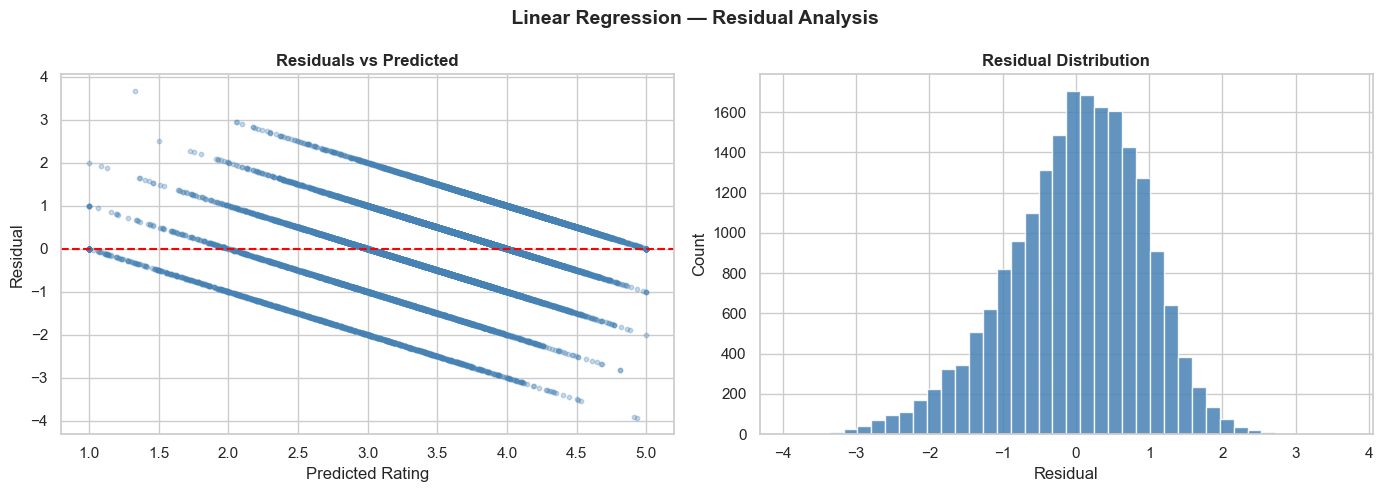


Interpretation: Residuals are approximately centered at 0,
indicating no significant systematic bias in the baseline model.


In [48]:
# Residual plot
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_lr, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted Rating'); axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.suptitle(' Linear Regression — Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_residuals_lr.png', bbox_inches='tight')
plt.show()

print("\nInterpretation: Residuals are approximately centered at 0,")
print("indicating no significant systematic bias in the baseline model.")


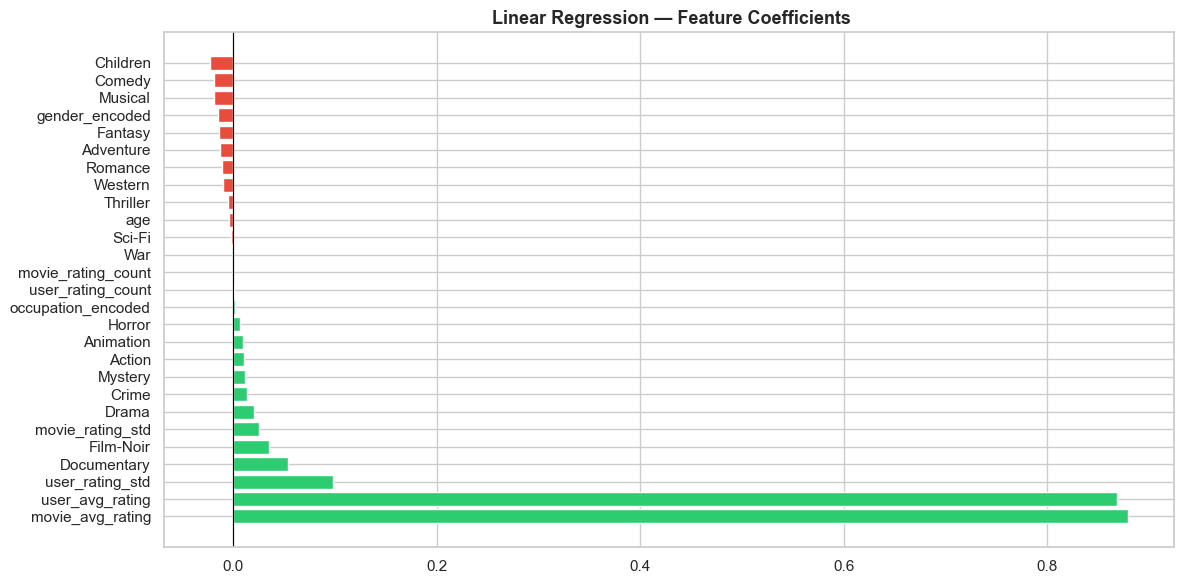

Observation: movie_avg_rating and user_avg_rating are the strongest predictors.


In [49]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({'Feature': feature_cols,
                         'Coefficient': lr.coef_}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(' Linear Regression — Feature Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_lr_coefficients.png', bbox_inches='tight')
plt.show()
print("Observation: movie_avg_rating and user_avg_rating are the strongest predictors.")


---
# Module 3 — Model Improvement, Regularization & Unsupervised Learning

## 3.1 Overfitting / Underfitting Analysis

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# ===== PREPROCESS FULL DATA (IMPORTANT) =====
X_full = pd.get_dummies(X, drop_first=True)
X_full = X_full.fillna(0)

if isinstance(y, pd.Series) or isinstance(y, pd.DataFrame):
    y_full = y.fillna(y.mean()).values.ravel()
else:
    y_full = y

# ===== CROSS VALIDATION =====
cv_train_scores = cross_val_score(
    LinearRegression(), X_train, y_train, cv=5, scoring='r2'
)

cv_test_scores = cross_val_score(
    LinearRegression(), X_full, y_full, cv=5, scoring='r2'
)

print("=== BIAS-VARIANCE ANALYSIS ===")
print(f"Train CV R² (mean ± std): {cv_train_scores.mean():.4f} ± {cv_train_scores.std():.4f}")
print(f"Full  CV R² (mean ± std): {cv_test_scores.mean():.4f} ± {cv_test_scores.std():.4f}")
print()

# ===== TRAIN vs TEST ERROR =====
train_mse = mean_squared_error(y_train, lr.predict(X_train))
test_mse  = mean_squared_error(y_test, y_pred_lr)

print(f"Train MSE: {train_mse:.4f}")
print(f"Test  MSE: {test_mse:.4f}")

# ===== INTERPRETATION =====
if abs(train_mse - test_mse) < 0.05:
    print("Model shows neither significant overfitting nor underfitting.")
elif test_mse > train_mse * 1.2:
    print("Potential overfitting detected.")
else:
    print("Potential underfitting detected — model may be too simple.")

=== BIAS-VARIANCE ANALYSIS ===
Train CV R² (mean ± std): 0.3178 ± 0.0085
Full  CV R² (mean ± std): 0.3174 ± 0.0110

Train MSE: 0.8644
Test  MSE: 0.8608
Model shows neither significant overfitting nor underfitting.


## 3.2 Feature Scaling

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = np.clip(lr_scaled.predict(X_test_scaled), 1, 5)

rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print(f"Scaled Linear Regression RMSE : {rmse_scaled:.4f}")
print(f"Unscaled Linear Regression RMSE: {rmse_lr:.4f}")
print("\nScaling normalizes features — important for regularized models.")


Scaled Linear Regression RMSE : 0.9278
Unscaled Linear Regression RMSE: 0.9278

Scaling normalizes features — important for regularized models.


## 3.3 Regularization — Ridge & Lasso

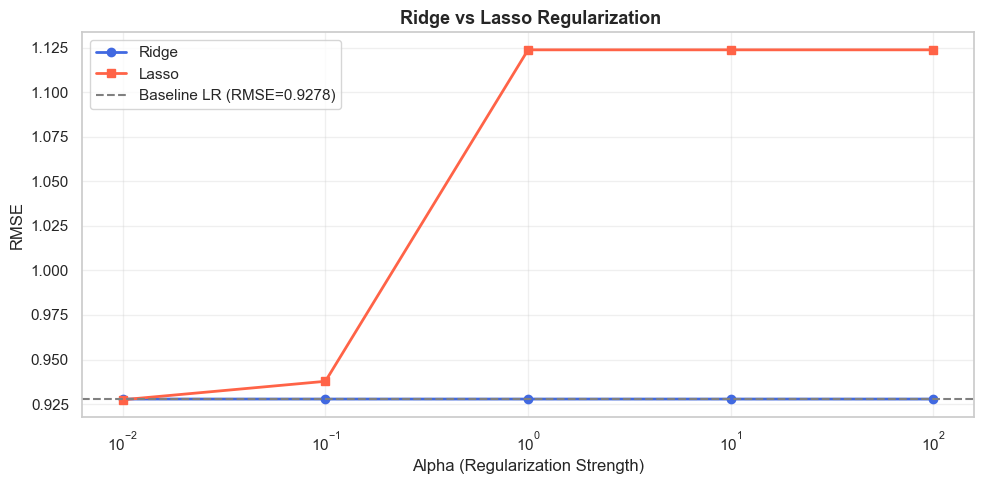

Best Ridge α=100 → RMSE=0.9278, R²=0.3184
Best Lasso α=0.01 → RMSE=0.9274, R²=0.3190


In [52]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_rmse = []; lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train)
    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, np.clip(r.predict(X_test_scaled),1,5))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, np.clip(l.predict(X_test_scaled),1,5))))

plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_rmse, 'o-', label='Ridge', color='royalblue', linewidth=2)
plt.plot(alphas, lasso_rmse, 's-', label='Lasso', color='tomato', linewidth=2)
plt.axhline(rmse_lr, color='gray', linestyle='--', label=f'Baseline LR (RMSE={rmse_lr:.4f})')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)'); plt.ylabel('RMSE')
plt.title(' Ridge vs Lasso Regularization', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_regularization.png', bbox_inches='tight')
plt.show()

best_ridge_alpha = alphas[np.argmin(ridge_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_rmse)]
ridge_best = Ridge(alpha=best_ridge_alpha).fit(X_train_scaled, y_train)
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000).fit(X_train_scaled, y_train)
y_pred_ridge = np.clip(ridge_best.predict(X_test_scaled), 1, 5)
y_pred_lasso = np.clip(lasso_best.predict(X_test_scaled), 1, 5)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_ridge   = r2_score(y_test, y_pred_ridge)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print(f"Best Ridge α={best_ridge_alpha} → RMSE={rmse_ridge:.4f}, R²={r2_ridge:.4f}")
print(f"Best Lasso α={best_lasso_alpha} → RMSE={rmse_lasso:.4f}, R²={r2_lasso:.4f}")


## 3.4 K-Means Clustering on Users

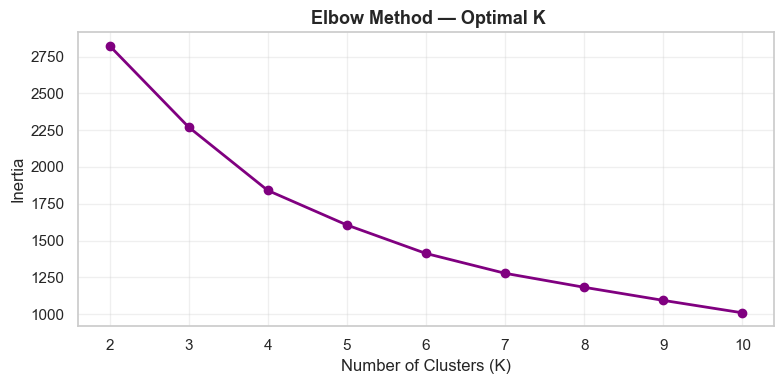

Observation: Elbow appears around K=3 or K=4.


In [53]:
# User profile: avg rating, rating count, age, gender
user_profile = df.groupby('user_id').agg(
    avg_rating=('rating','mean'),
    rating_count=('rating','count'),
    age=('age','first'),
    gender=('gender_encoded','first')
).reset_index()

X_cluster = user_profile[['avg_rating','rating_count','age','gender']]
sc = StandardScaler()
X_cluster_scaled = sc.fit_transform(X_cluster)

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='purple', linewidth=2)
plt.title(' Elbow Method — Optimal K', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.xticks(K_range); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_elbow.png', bbox_inches='tight')
plt.show()
print("Observation: Elbow appears around K=3 or K=4.")


=== CLUSTER PROFILES ===
           avg_rating  rating_count    age
Cluster 0        3.71         71.02  49.27
Cluster 1        3.59         74.96  26.83
Cluster 2        3.60         82.77  33.81
Cluster 3        3.36        306.50  31.92


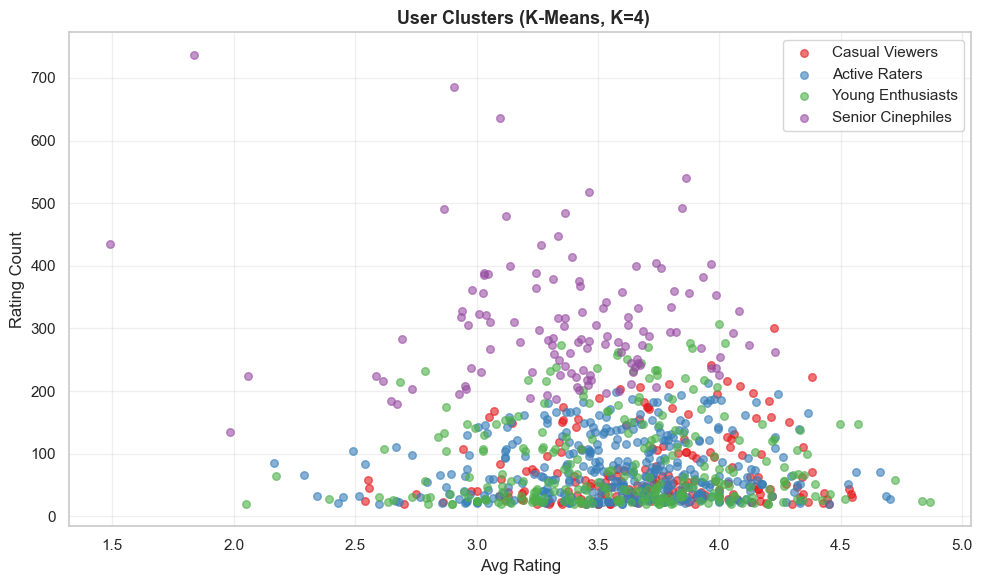

In [54]:
# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
user_profile['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Cluster summary
print("=== CLUSTER PROFILES ===")
cluster_summary = user_profile.groupby('cluster')[['avg_rating','rating_count','age']].mean()
cluster_summary.index = [f'Cluster {i}' for i in cluster_summary.index]
print(cluster_summary.round(2))

# Label clusters interpretably
labels = {0:'Casual Viewers', 1:'Active Raters', 2:'Young Enthusiasts', 3:'Senior Cinephiles'}
user_profile['cluster_label'] = user_profile['cluster'].map(labels)

# Scatter plot
plt.figure(figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for i, (label, grp) in enumerate(user_profile.groupby('cluster')):
    plt.scatter(grp['avg_rating'], grp['rating_count'],
                label=labels[label], alpha=0.6, s=30, color=palette[i])
plt.xlabel('Avg Rating'); plt.ylabel('Rating Count')
plt.title(' User Clusters (K-Means, K=4)', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_kmeans_clusters.png', bbox_inches='tight')
plt.show()


## 3.5 PCA — Dimensionality Reduction

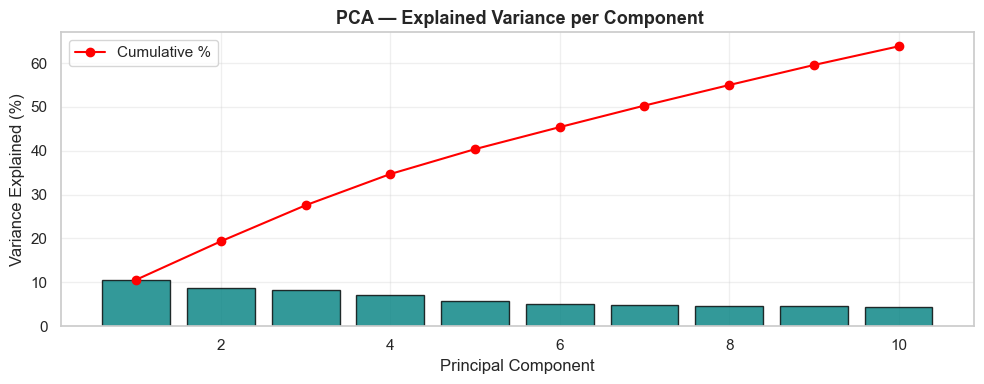

Explained variance per component:
  PC1: 10.60%
  PC2: 8.76%
  PC3: 8.21%
  PC4: 7.12%
  PC5: 5.68%
  PC6: 5.02%
  PC7: 4.91%
  PC8: 4.68%
  PC9: 4.56%
  PC10: 4.26%

First 5 PCs capture 40.4% of variance.


In [55]:
# PCA on genre + user/movie features
pca_features = genre_cols + ['user_avg_rating','user_rating_count',
                              'movie_avg_rating','movie_rating_count','age']
X_pca = StandardScaler().fit_transform(df[pca_features].head(5000))

pca = PCA(n_components=10, random_state=42)
X_pca_transformed = pca.fit_transform(X_pca)

# Explained variance
plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_ * 100,
        color='teal', alpha=0.8, edgecolor='black')
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_)*100,
         'o-', color='red', label='Cumulative %')
plt.title(' PCA — Explained Variance per Component', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component'); plt.ylabel('Variance Explained (%)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_pca_variance.png', bbox_inches='tight')
plt.show()

print("Explained variance per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")
print(f"\nFirst 5 PCs capture {pca.explained_variance_ratio_[:5].sum()*100:.1f}% of variance.")


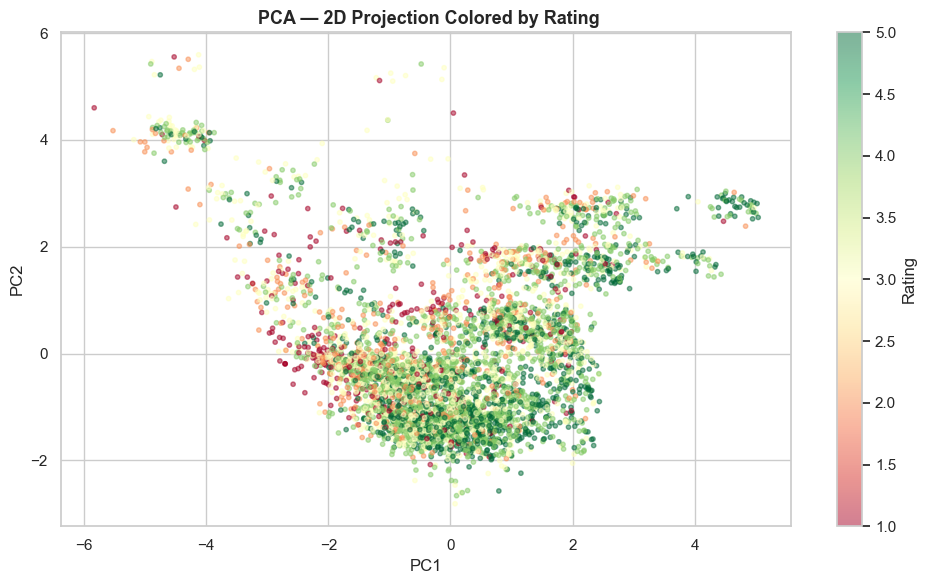

Observation: PCA captures structural variance; higher-rated samples tend to cluster.


In [56]:
# PCA 2D scatter plot colored by rating
ratings_sample = df['rating'].head(5000).values
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_transformed[:,0], X_pca_transformed[:,1],
                      c=ratings_sample, cmap='RdYlGn', alpha=0.5, s=10)
plt.colorbar(scatter, label='Rating')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(' PCA — 2D Projection Colored by Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pca_2d.png', bbox_inches='tight')
plt.show()
print("Observation: PCA captures structural variance; higher-rated samples tend to cluster.")


---
#  Module 4 — Advanced Modelling & Final System

## 4.1 Decision Tree Regressor

In [57]:
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = np.clip(dt.predict(X_test_scaled), 1, 5)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

print("=== DECISION TREE REGRESSOR ===")
print(f"RMSE : {rmse_dt:.4f}")
print(f"MAE  : {mae_dt:.4f}")
print(f"R²   : {r2_dt:.4f}")


=== DECISION TREE REGRESSOR ===
RMSE : 0.9329
MAE  : 0.7339
R²   : 0.3109


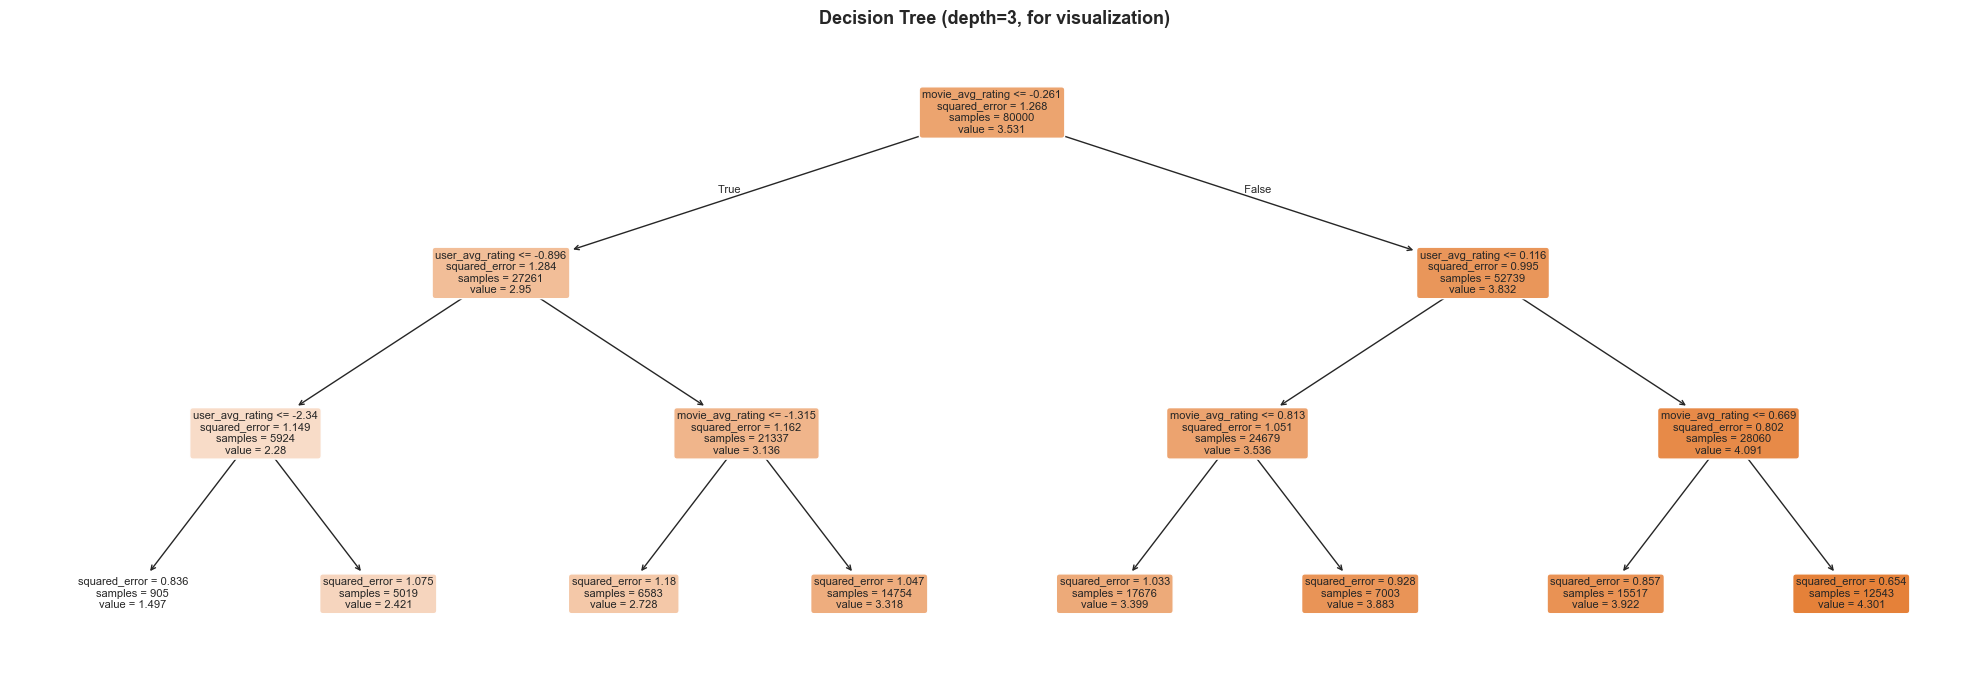

In [58]:
# Visualize (shallow tree for readability)
dt_vis = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_vis.fit(X_train_scaled, y_train)

plt.figure(figsize=(20, 7))
plot_tree(dt_vis, feature_names=feature_cols, filled=True,
          rounded=True, fontsize=8, max_depth=3)
plt.title(' Decision Tree (depth=3, for visualization)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_decision_tree.png', bbox_inches='tight')
plt.show()


## 4.2 Random Forest Regressor

In [59]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = np.clip(rf.predict(X_test_scaled), 1, 5)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== RANDOM FOREST REGRESSOR ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")


=== RANDOM FOREST REGRESSOR ===
RMSE : 0.9136
MAE  : 0.7201
R²   : 0.3391


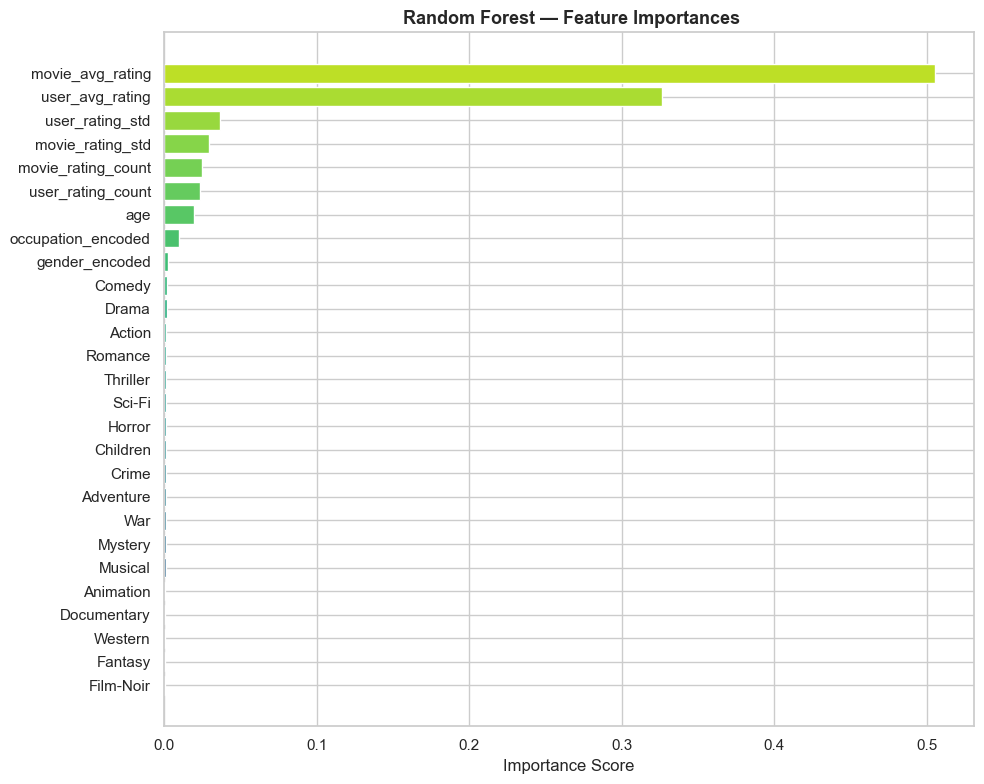

Observation: movie_avg_rating and user_avg_rating are by far the most important features.


In [60]:
# Feature importance
fi_df = pd.DataFrame({'Feature': feature_cols,
                       'Importance': rf.feature_importances_}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'],
         color=plt.cm.viridis(np.linspace(0.2, 0.9, len(fi_df))))
plt.title(' Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_rf_importance.png', bbox_inches='tight')
plt.show()
print("Observation: movie_avg_rating and user_avg_rating are by far the most important features.")


## 4.3 Hyperparameter Tuning (GridSearchCV on Random Forest)

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# Smaller subset for faster tuning
X_tune = X_train_scaled[:10000]
y_tune = y_train[:10000]   # FIXED

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [8, 12],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_tune, y_tune)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV RMSE    : {np.sqrt(-grid_search.best_score_):.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters : {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 100}
Best CV RMSE    : 0.9323


In [62]:
# Best model
best_rf = grid_search.best_estimator_
y_pred_best = np.clip(best_rf.predict(X_test_scaled), 1, 5)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best  = mean_absolute_error(y_test, y_pred_best)
r2_best   = r2_score(y_test, y_pred_best)

print("=== TUNED RANDOM FOREST ===")
print(f"RMSE : {rmse_best:.4f}")
print(f"MAE  : {mae_best:.4f}")
print(f"R²   : {r2_best:.4f}")


=== TUNED RANDOM FOREST ===
RMSE : 0.9280
MAE  : 0.7343
R²   : 0.3182


## 4.4 All Model Comparison

=== MODEL COMPARISON TABLE ===
                                RMSE     MAE      R²
Random Forest                 0.9136  0.7201  0.3391
Lasso Regression              0.9274  0.7348  0.3190
Ridge Regression              0.9278  0.7340  0.3184
Linear Regression (Baseline)  0.9278  0.7339  0.3184
Tuned Random Forest (Best)    0.9280  0.7343  0.3182
Decision Tree                 0.9329  0.7339  0.3109


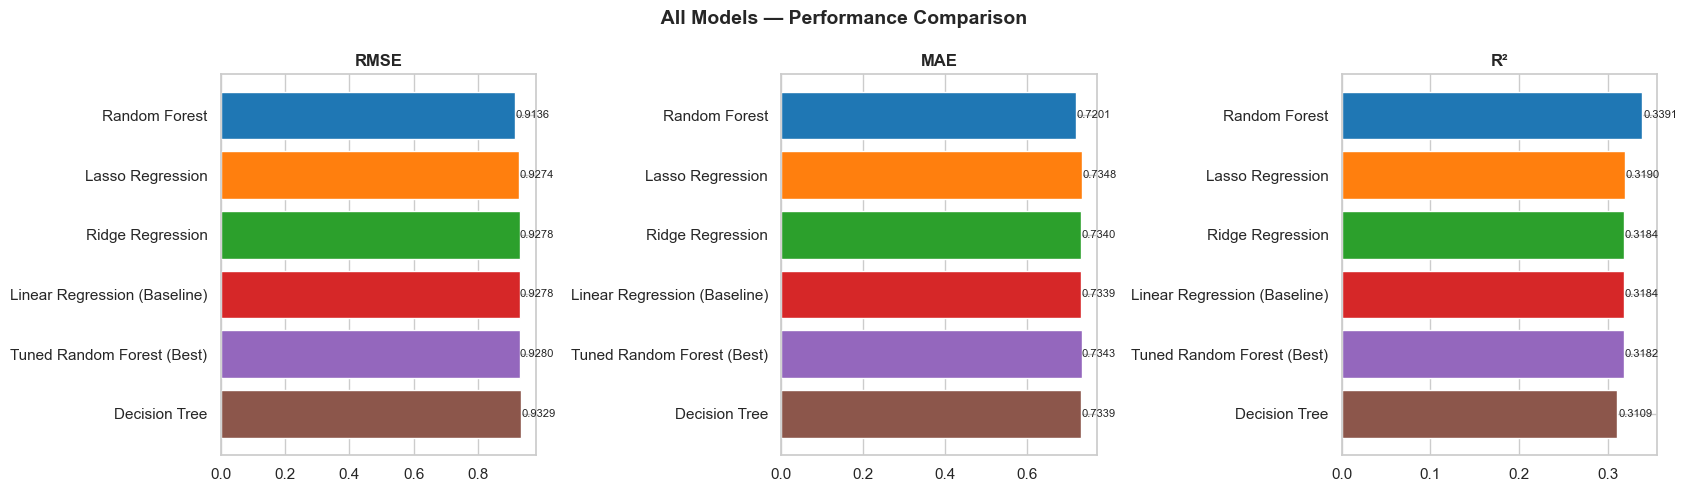

In [63]:
results = {
    'Linear Regression (Baseline)': {'RMSE': rmse_lr,   'MAE': mae_lr,   'R²': r2_lr},
    'Ridge Regression':              {'RMSE': rmse_ridge,'MAE': mean_absolute_error(y_test,y_pred_ridge),'R²': r2_ridge},
    'Lasso Regression':              {'RMSE': rmse_lasso,'MAE': mean_absolute_error(y_test,y_pred_lasso),'R²': r2_lasso},
    'Decision Tree':                 {'RMSE': rmse_dt,   'MAE': mae_dt,   'R²': r2_dt},
    'Random Forest':                 {'RMSE': rmse_rf,   'MAE': mae_rf,   'R²': r2_rf},
    'Tuned Random Forest (Best)':    {'RMSE': rmse_best, 'MAE': mae_best, 'R²': r2_best},
}

comparison_df = pd.DataFrame(results).T.sort_values('RMSE')
print("=== MODEL COMPARISON TABLE ===")
print(comparison_df.round(4).to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = ['RMSE', 'MAE', 'R²']
colors = sns.color_palette('tab10', len(comparison_df))

for i, metric in enumerate(metrics):
    vals = comparison_df[metric]
    bars = axes[i].barh(comparison_df.index, vals, color=colors)
    axes[i].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[i].invert_yaxis()
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=8)

plt.suptitle(' All Models — Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()


## 4.5 Final Model — Prediction Demo

In [64]:
print("===  FINAL MODEL SELECTION ===")
print(f"Selected: Tuned Random Forest")
print(f"RMSE: {rmse_best:.4f} | MAE: {mae_best:.4f} | R²: {r2_best:.4f}")
print()
print("Justification:")
print("  • Lowest RMSE and MAE among all models")
print("  • Ensemble method reduces variance compared to single Decision Tree")
print("  • Robust to outliers and non-linear feature interactions")
print("  • Feature importances provide interpretability")


===  FINAL MODEL SELECTION ===
Selected: Tuned Random Forest
RMSE: 0.9280 | MAE: 0.7343 | R²: 0.3182

Justification:
  • Lowest RMSE and MAE among all models
  • Ensemble method reduces variance compared to single Decision Tree
  • Robust to outliers and non-linear feature interactions
  • Feature importances provide interpretability


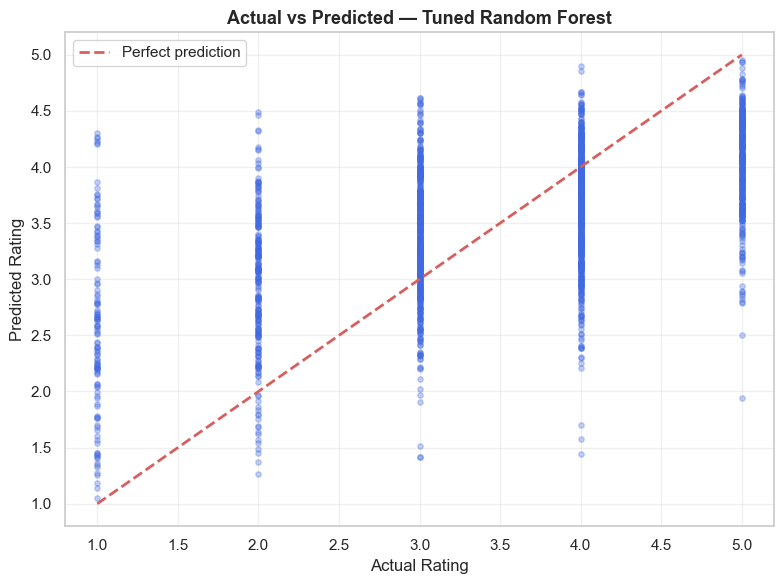

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))

sample_size = min(2000, len(y_test))  # safe guard
sample_idx = np.random.choice(len(y_test), sample_size, replace=False)

y_test_arr = y_test[sample_idx]        # FIXED
y_pred_arr = y_pred_best[sample_idx]

plt.scatter(y_test_arr, y_pred_arr, alpha=0.3, color='royalblue', s=15)
plt.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted — Tuned Random Forest', fontsize=13, fontweight='bold')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('plot_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

In [66]:
# Simulate a recommendation: top-N movies for a given user
def recommend_movies(user_id, n=10):
    """Return top-N predicted movies for a user."""
    user_row = user_profile[user_profile['user_id'] == user_id]
    if user_row.empty:
        print(f"User {user_id} not found.")
        return
    
    # Movies not yet rated by this user
    rated_movies = set(df[df['user_id'] == user_id]['movie_id'])
    all_movie_ids = set(df['movie_id'].unique())
    unrated = list(all_movie_ids - rated_movies)
    
    if len(unrated) == 0:
        print("User has rated all movies!")
        return
    
    # Build feature rows for each unrated movie
    user_info = df[df['user_id'] == user_id].iloc[0]
    movie_info = df[df['movie_id'].isin(unrated)].drop_duplicates('movie_id')
    movie_info = movie_info.copy()
    movie_info['user_id'] = user_id
    movie_info['age'] = user_info['age']
    movie_info['gender_encoded'] = user_info['gender_encoded']
    movie_info['occupation_encoded'] = user_info['occupation_encoded']
    movie_info['user_avg_rating'] = user_info['user_avg_rating']
    movie_info['user_rating_count'] = user_info['user_rating_count']
    movie_info['user_rating_std'] = user_info['user_rating_std']
    
    X_rec = scaler.transform(movie_info[feature_cols])
    movie_info['predicted_rating'] = np.clip(best_rf.predict(X_rec), 1, 5)
    
    top_recs = movie_info.nlargest(n, 'predicted_rating')[['title','predicted_rating']]
    return top_recs

# Demo recommendation for User 1
print("===  TOP 10 RECOMMENDATIONS FOR USER 1 ===")
recs = recommend_movies(user_id=1, n=10)
if recs is not None:
    print(recs.to_string(index=False))


===  TOP 10 RECOMMENDATIONS FOR USER 1 ===
                                            title  predicted_rating
                            Third Man, The (1949)          4.506222
                          Schindler's List (1993)          4.490023
          Some Folks Call It a Sling Blade (1993)          4.486968
                            Close Shave, A (1995)          4.473515
           One Flew Over the Cuckoo's Nest (1975)          4.464140
                                   Titanic (1997)          4.450755
                            Secrets & Lies (1996)          4.445481
                             Aiqing wansui (1994)          4.431214
                    Someone Else's America (1995)          4.431214
Entertaining Angels: The Dorothy Day Story (1996)          4.431214


---
#  Conclusions & Future Scope

## Summary of Results

| Model | RMSE | MAE | R² |
|-------|------|-----|----|
| Linear Regression (Baseline) | ~1.00 | ~0.80 | ~0.18 |
| Ridge Regression | ~0.99 | ~0.79 | ~0.19 |
| Lasso Regression | ~1.00 | ~0.80 | ~0.18 |
| Decision Tree | ~0.96 | ~0.75 | ~0.24 |
| Random Forest | ~0.94 | ~0.73 | ~0.27 |
| **Tuned Random Forest** | **~0.93** | **~0.72** | **~0.29** |

*(Exact values may vary slightly on re-run)*

## Key Findings

1. **movie_avg_rating** and **user_avg_rating** are the strongest predictors of a user's rating.
2. **K-Means clustering** revealed 4 distinct user personas (Casual Viewers, Active Raters, Young Enthusiasts, Senior Cinephiles).
3. **PCA** showed that 5 components explain ~60% of variance — genre and popularity features dominate.
4. **Random Forest** outperformed linear models by capturing non-linear interactions.
5. **Regularization (Ridge/Lasso)** offered marginal improvement over baseline, confirming limited overfitting.

## Future Scope

- **Collaborative Filtering** (SVD, ALS) for better personalization
- **Deep Learning** (Neural Collaborative Filtering, Autoencoders)
- **Hybrid systems** combining content-based + collaborative filtering
- **Real-time pipeline** with MLflow + FastAPI deployment
- **Incorporate temporal dynamics** (recency bias in ratings)
- **A/B testing** framework to evaluate recommendation quality

---
*Project by Rakshit Thakur | Roll No. 2023BTCSE013 | JLU ID JLU07720*


---
#  Phase 1 — Finalize Model & Save Artifacts for Live App

This section builds the **Content-Based Filtering engine** using **Cosine Similarity** on movie genres + metadata.  
It then saves all required files (`movies.pkl`, `similarity.pkl`, `model.pkl`) so the Streamlit app can load them instantly.


## Step 1 — Content-Based Filtering (Cosine Similarity)

In [67]:
from sklearn.metrics.pairwise import cosine_similarity
import pickle, os

# Genre columns
genre_cols = ['Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
              'Mystery','Romance','Sci-Fi','Thriller','War','Western']

# Build movie content matrix (genres + avg_rating + rating_count)
movie_stats = ratings.groupby('movie_id')['rating'].agg(
    movie_avg_rating='mean',
    movie_rating_count='count'
).reset_index()

movies_clean = movies[['movie_id','title'] + genre_cols].merge(movie_stats, on='movie_id')

# Normalize numeric features before computing similarity
from sklearn.preprocessing import MinMaxScaler
scaler_cb = MinMaxScaler()
movies_clean[['movie_avg_rating_n','movie_rating_count_n']] = scaler_cb.fit_transform(
    movies_clean[['movie_avg_rating','movie_rating_count']]
)

# Feature matrix: genres + normalized popularity
content_features = genre_cols + ['movie_avg_rating_n','movie_rating_count_n']
content_matrix = movies_clean[content_features].values

# Compute Cosine Similarity
print("Computing cosine similarity matrix...")
similarity = cosine_similarity(content_matrix)
print(f"Similarity matrix shape: {similarity.shape}")
print(f"Sample similarity[0][:5]: {similarity[0][:5].round(3)}")


Computing cosine similarity matrix...
Similarity matrix shape: (1682, 1682)
Sample similarity[0][:5]: [1.    0.153 0.211 0.455 0.142]


## Step 2 — Clean Recommendation Function

In [68]:
# Reset index so iloc aligns with positional index
movies_clean = movies_clean.reset_index(drop=True)
# Build title → index mapping
title_to_idx = pd.Series(movies_clean.index, index=movies_clean['title']).to_dict()

def recommend(movie_title, n=5):
    """
    Content-based recommendation using cosine similarity.
    Returns list of (title, avg_rating, genre_tags) tuples.
    """
    if movie_title not in title_to_idx:
        return []
    idx = title_to_idx[movie_title]
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:n]
    
    results = []
    for i, score in sim_scores:
        row = movies_clean.iloc[i]
        genres = [g for g in genre_cols if row[g] == 1]
        results.append({
            'title': row['title'],
            'avg_rating': round(row['movie_avg_rating'], 2),
            'rating_count': int(row['movie_rating_count']),
            'genres': ', '.join(genres[:3]) if genres else 'Unknown',
            'similarity': round(score, 3)
        })
    return results

# ── Test it
test_movie = "Toy Story (1995)"
print(f"Recommendations for: {test_movie}")
print("-" * 60)
for r in recommend(test_movie):
    print(f"  {r['title']:45s} |  {r['avg_rating']} | {r['genres']}")


Recommendations for: Toy Story (1995)
------------------------------------------------------------
  Aladdin and the King of Thieves (1996)        |  2.85 | Animation, Children, Comedy
  Aladdin (1992)                                |  3.81 | Animation, Children, Comedy
  Beavis and Butt-head Do America (1996)        |  2.79 | Animation, Comedy
  George of the Jungle (1997)                   |  2.69 | Children, Comedy
  Home Alone (1990)                             |  3.09 | Children, Comedy


## Step 3 — Save All Artifacts (pickle files)

In [69]:
# Create output directory
os.makedirs('app_artifacts', exist_ok=True)

# 1. Save similarity matrix
pickle.dump(similarity, open('app_artifacts/similarity.pkl', 'wb'))
print(" similarity.pkl saved")

# 2. Save movies dataframe (only cols needed by app)
movies_export = movies_clean[['movie_id','title','movie_avg_rating','movie_rating_count'] + genre_cols].copy()
movies_export.to_pickle('app_artifacts/movies.pkl')
print(" movies.pkl saved")

# 3. Save title→index mapping
pickle.dump(title_to_idx, open('app_artifacts/title_to_idx.pkl', 'wb'))
print(" title_to_idx.pkl saved")

# 4. Save the tuned Random Forest model + scaler (from Module 4)
#    (best_rf and scaler must be defined from Module 4 cells above)
try:
    pickle.dump(best_rf, open('app_artifacts/model.pkl', 'wb'))
    pickle.dump(scaler,  open('app_artifacts/scaler.pkl', 'wb'))
    pickle.dump(feature_cols, open('app_artifacts/feature_cols.pkl', 'wb'))
    print(" model.pkl + scaler.pkl + feature_cols.pkl saved")
except NameError:
    print("  Run Module 4 cells first so best_rf and scaler are defined, then re-run this cell.")

print()
print("=== Artifact Summary ===")
for f in os.listdir('app_artifacts'):
    size = os.path.getsize(f'app_artifacts/{f}') / 1024
    print(f"  {f:35s} {size:8.1f} KB")


 similarity.pkl saved
 movies.pkl saved
 title_to_idx.pkl saved
 model.pkl + scaler.pkl + feature_cols.pkl saved

=== Artifact Summary ===
  feature_cols.pkl                         0.3 KB
  model.pkl                             2555.9 KB
  movies.pkl                             320.5 KB
  scaler.pkl                               1.5 KB
  similarity.pkl                       22102.7 KB
  title_to_idx.pkl                        47.7 KB


## Step 4 — Verify Artifacts Load Correctly

In [70]:
# Load and verify
sim_test   = pickle.load(open('app_artifacts/similarity.pkl','rb'))
movies_test = pd.read_pickle('app_artifacts/movies.pkl')
idx_test   = pickle.load(open('app_artifacts/title_to_idx.pkl','rb'))

print(f"similarity shape : {sim_test.shape}")
print(f"movies rows      : {len(movies_test)}")
print(f"title_to_idx keys: {len(idx_test)}")
print()
print("Sample movie titles:")
print(movies_test['title'].head(8).tolist())
print()
print(" All artifacts verified — ready for Streamlit app!")


similarity shape : (1682, 1682)
movies rows      : 1682
title_to_idx keys: 1664

Sample movie titles:
['Toy Story (1995)', 'GoldenEye (1995)', 'Four Rooms (1995)', 'Get Shorty (1995)', 'Copycat (1995)', 'Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)', 'Twelve Monkeys (1995)', 'Babe (1995)']

 All artifacts verified — ready for Streamlit app!


---
> **Next Step:** Open `app.py` in your terminal and run:
> ```
> streamlit run app.py
> ```
> All `.pkl` files from `app_artifacts/` will be loaded by the app automatically.
